# Sales Forecasting with Python

In this notebook we build two simple forecasting models step by step:
1. **Linear Regression** – a baseline model assuming linear relationships between features and sales.
2. **Decision Tree Regressor** – a non-linear model that can capture more complex patterns.

Both models are from the [`scikit-learn`](https://scikit-learn.org/) library.

## Step 1 – Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Step 2 – Load the Dataset

In [ ]:
file_path = "https://raw.github.com/jan-source/course_business_analytics_students/main/python/prediction/models/sales_forecast_sample.csv"

df = pd.read_csv(file_path)

print('Shape:', df.shape)
df.head()

Shape: (730, 5)


,date,is_promotion,is_holiday,price,sales
0,2023-01-01,0,0,16.642658,157.048999
1,2023-01-02,1,0,23.145747,142.313639
2,2023-01-03,0,0,21.651972,129.859584
3,2023-01-04,0,0,20.230654,122.201694
4,2023-01-05,0,0,18.588305,132.456355


## Step 3 – Feature Engineering

The `date` column is just a string right now. We convert it to a proper datetime object and then extract useful numerical features that a machine learning model can work with.

In [3]:
df['date'] = pd.to_datetime(df['date'])

# Extract temporal features
df['day_of_week'] = df['date'].dt.dayofweek   # Monday=0, Sunday=6
df['month']       = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear

df.head()

,date,is_promotion,is_holiday,price,sales,day_of_week,month,day_of_year
0,2023-01-01,0,0,16.642658,157.048999,6,1,1
1,2023-01-02,1,0,23.145747,142.313639,0,1,2
2,2023-01-03,0,0,21.651972,129.859584,1,1,3
3,2023-01-04,0,0,20.230654,122.201694,2,1,4
4,2023-01-05,0,0,18.588305,132.456355,3,1,5


## Step 4 – Define Features and Target

- **Features (X)**: the columns we use to make the prediction.
- **Target (y)**: the column we want to predict (`sales`).

In [4]:
feature_columns = ['is_promotion', 'is_holiday', 'price', 'day_of_week', 'month', 'day_of_year']

X = df[feature_columns]
y = df['sales']

print('Features shape:', X.shape)
print('Target shape:  ', y.shape)

Features shape: (730, 6)
Target shape:   (730,)


## Step 5 – Split into Training and Test Sets

We use a **temporal (chronological) split**: the first 80 % of rows are used for training and the last 20 % for testing.  
Setting `shuffle=False` is important for time-series data – we must not train on future data.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print('Training samples:', len(X_train))
print('Test samples:    ', len(X_test))

Training samples: 584
Test samples:     146


## Step 6 – Model 1: Linear Regression

Linear Regression tries to fit a straight line (or hyperplane) through the data. It learns how each feature linearly affects the sales number.

In [6]:
# Create and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on the test set
lr_predictions = lr_model.predict(X_test)

In [7]:
# Evaluate the model
lr_mae  = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

print(f'Linear Regression – MAE:  {lr_mae:.2f}')
print(f'Linear Regression – RMSE: {lr_rmse:.2f}')

Linear Regression – MAE:  20.71
Linear Regression – RMSE: 22.80


### How to read the metrics
| Metric | What it measures |
|--------|------------------|
| **MAE** (Mean Absolute Error) | Average absolute difference between predicted and actual sales |
| **RMSE** (Root Mean Squared Error) | Similar to MAE but penalises large errors more heavily |

## Step 7 – Model 2: Decision Tree Regressor

A Decision Tree splits the data into smaller and smaller groups based on feature thresholds. It can capture non-linear patterns and interactions between features.  
`max_depth=5` limits how deep the tree grows to avoid overfitting.

In [8]:
# Create and train the model
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the test set
dt_predictions = dt_model.predict(X_test)

In [9]:
# Evaluate the model
dt_mae  = mean_absolute_error(y_test, dt_predictions)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))

print(f'Decision Tree – MAE:  {dt_mae:.2f}')
print(f'Decision Tree – RMSE: {dt_rmse:.2f}')

Decision Tree – MAE:  22.32
Decision Tree – RMSE: 24.54


## Step 8 – Compare Both Models

Let us print a side-by-side comparison of both models.

In [10]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree'],
    'MAE':   [lr_mae,  dt_mae],
    'RMSE':  [lr_rmse, dt_rmse]
})

results

,Model,MAE,RMSE
0,Linear Regression,20.706740,22.799475
1,Decision Tree,22.323932,24.542250


## Step 9 – Visualise the Predictions

Plot the actual sales alongside the predictions from both models for the test period.

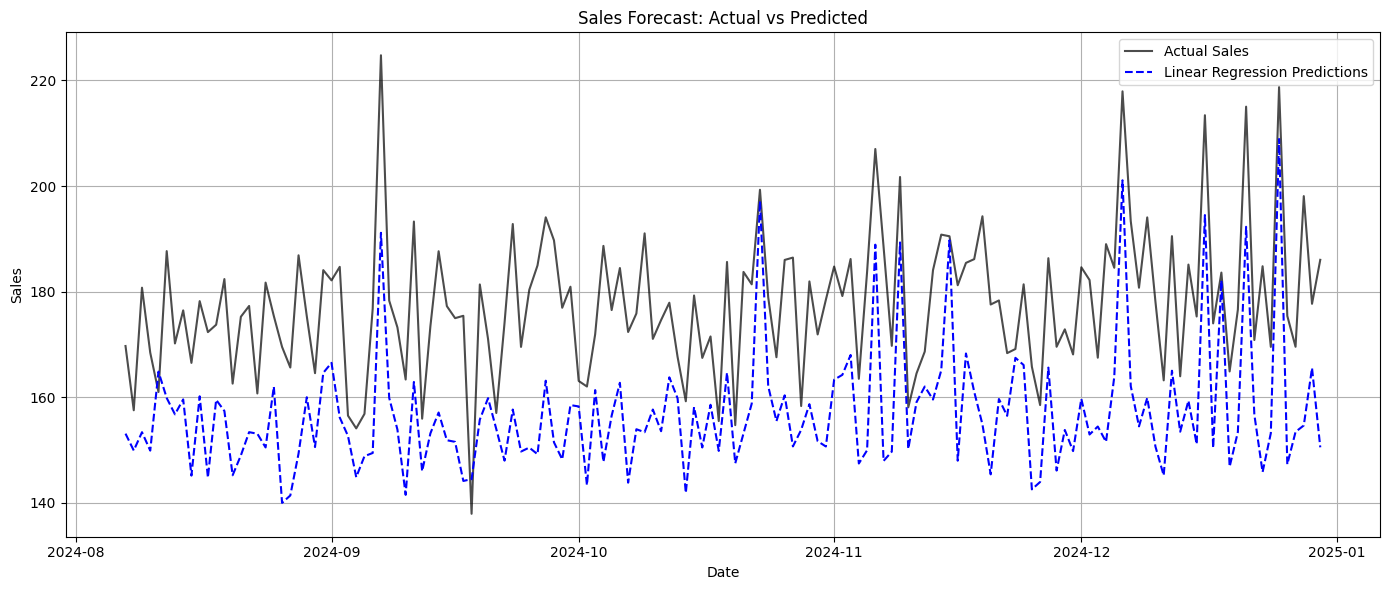

In [14]:
test_dates = df.loc[X_test.index, 'date']

plt.figure(figsize=(14, 6))

plt.plot(test_dates, y_test.values,      label='Actual Sales',                   color='black', alpha=0.7)
plt.plot(test_dates, lr_predictions,     label='Linear Regression Predictions',  color='blue',  linestyle='--')

plt.title('Sales Forecast: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

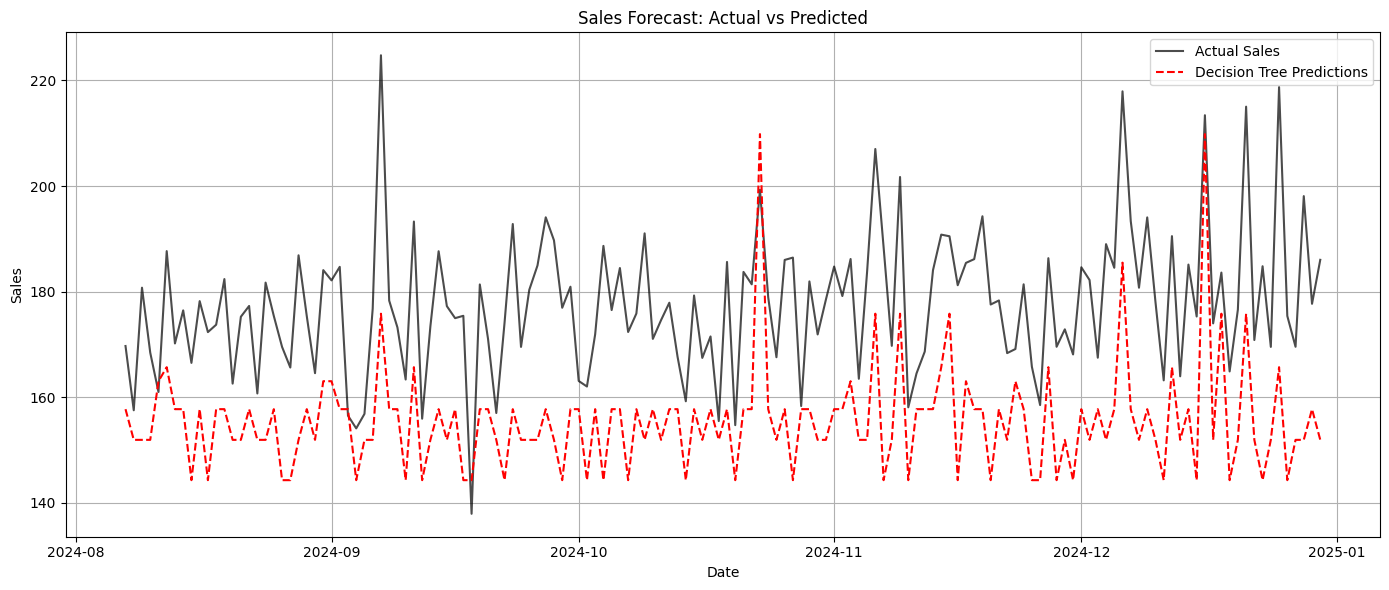

In [13]:
test_dates = df.loc[X_test.index, 'date']

plt.figure(figsize=(14, 6))

plt.plot(test_dates, y_test.values,      label='Actual Sales',                   color='black', alpha=0.7)
plt.plot(test_dates, dt_predictions,     label='Decision Tree Predictions',       color='red', linestyle='--')

plt.title('Sales Forecast: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Summary

| Step | What we did |
|------|-------------|
| 1 | Imported required libraries |
| 2 | Loaded the sales dataset |
| 3 | Extracted temporal features from the date column |
| 4 | Defined features (X) and target (y) |
| 5 | Split data chronologically into train/test |
| 6 | Trained and evaluated a **Linear Regression** model |
| 7 | Trained and evaluated a **Decision Tree** model |
| 8 | Compared both models with MAE and RMSE |
| 9 | Visualised actual vs predicted sales |

**Next steps** you could explore:
- Try other models like `RandomForestRegressor` or `GradientBoostingRegressor`.
- Add lag features (e.g., sales from the previous day) to give the model more context.
- Use cross-validation designed for time-series (`TimeSeriesSplit`).